<a href="https://colab.research.google.com/github/ISO158/udemy-deep-learning-cohen/blob/main/05_learning_rates_comparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Learning rates comparison

How to put the model-creation and model-training code into callable functions.

How to run parametric experiments with ANN models.

The effects of learning rate on perfimance.

That puzzling results provide a great leraning opportunity!



In [6]:
# import libraries
import torch
import torch.nn as nn
import numpy as np

import matplotlib.pyplot as plt
from IPython import display
display.set_matplotlib_formats('svg')

/tmp/ipykernel_860/3733693253.py:8: DeprecationWarning: `set_matplotlib_formats` is deprecated since IPython 7.23, directly use `matplotlib_inline.backend_inline.set_matplotlib_formats()`
  display.set_matplotlib_formats('svg')


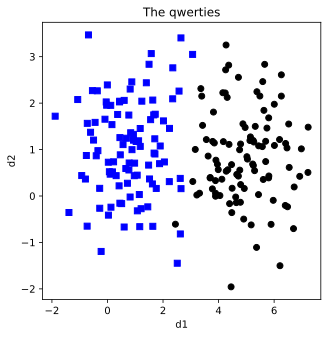

In [7]:
# create data

nPerClust = 100
blur = 1

#specify the center of the data clouds
A = [1,1]
B = [5,1]

# generate data
a = [A[0]+np.random.randn(nPerClust)*blur, A[1]+np.random.randn(nPerClust)*blur]
b = [B[0]+np.random.randn(nPerClust)*blur, B[1]+np.random.randn(nPerClust)*blur]

# true labels
labels_np = np.vstack((np.zeros((nPerClust,1)), np.ones((nPerClust,1))))
# I'm categoryze the data using the sentence above

# concatanate into a matrix
data_np = np.hstack((a,b)).T

# convert to a pytorch tensor
data = torch.tensor(data_np).float()
labels = torch.tensor(labels_np).float()

# show the data
fig = plt.figure(figsize=(5,5))
plt.plot(data[np.where(labels==0)[0],0],data[np.where(labels==0)[0],1],'bs')
plt.plot(data[np.where(labels==1)[0],0],data[np.where(labels==1)[0],1],'ko')
plt.title('The qwerties')
plt.xlabel('d1')
plt.ylabel('d2')
plt.show()

### Functions to build and train the model

In [8]:
def createANNmodel(learningRate):
  # model architecture
  ANNclassify = nn.Sequential(
      nn.Linear(2,1), # input layer
      nn.ReLU(),      # acativation unit
      nn.Linear(1,1)  # output unit
      # nn.sigmoid(), # final activation unit
  )

  # loss function
  lossfun = nn.BCEWithLogitsLoss()

  #optimizer
  optimizer = torch.optim.SGD(ANNclassify.parameters(), lr=learningRate)

  # model output
  return ANNclassify, lossfun, optimizer

In [13]:
# another have a function that trains the model

# a fixed parameter

numepochs = 1000

def trainTheModel(ANNmodel):

  # initialize losses
  losses = torch.zeros(numepochs)

  # loop over epochs
  for epochi in range(numepochs):

    # forward pass
    yHat = ANNmodel(data)

    # comput loss
    loss = lossfun(yHat,labels) # yHat is model prediction
    losses[epochi] = loss

    # backprop
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()


  # final forward pass
  predictions = ANNmodel(data)

  # compute the predictions and report accuracy
  # NOTE: shouldn't it be predictions>.5??
  totalacc = 100*torch.mean(((predictions>0) == labels).float())

  return losses, predictions, totalacc


### Test the new code by running it once

Final accuracy: 97.5%


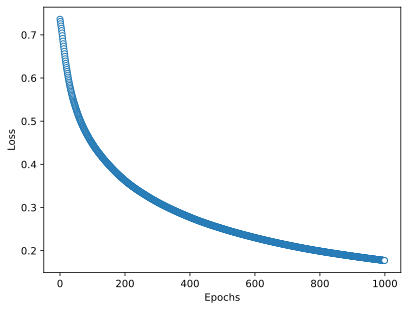

In [14]:
# create everything

ANNclassify, lossfun, optimizer = createANNmodel(0.01)

# run it
losses, predictions, totalacc = trainTheModel(ANNclassify)

# report accuracy
print('Final accuracy: %g%%' %totalacc)

#show the losses
plt.plot(losses.detach(),'o',markerfacecolor='w',linewidth=.1)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()

## Now for the experiment

In [15]:
# the set of learning rates to test
learningrates = np.linspace(.001,.1,40)

# initialize result output
accByLR =[]
allLosses = np.zeros((len(learningrates),numepochs))

# loop throught learning rates
for i,lr in enumerate(learningrates):

  # create and run the model
  ANNclassify, lossfun, optimizer = createANNmodel(lr)
  losses, predictions, totalacc = trainTheModel(ANNclassify)

  # save the results
  accByLR.append(totalacc)
  allLosses[i,:] = losses.detach()


/tmp/ipykernel_860/1236479036.py:17: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  allLosses[i,:] = losses.detach()


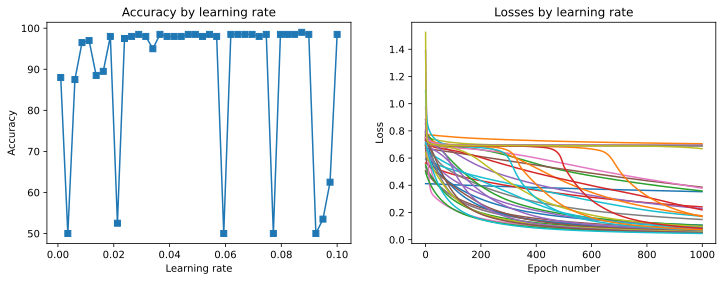

In [16]:
# plot the results
fig,ax = plt.subplots(1,2,figsize=(12,4))

ax[0].plot(learningrates,accByLR,'s-')
ax[0].set_xlabel('Learning rate')
ax[0].set_ylabel('Accuracy')
ax[0].set_title('Accuracy by learning rate')

ax[1].plot(allLosses.T)
ax[1].set_title('Losses by learning rate')
ax[1].set_xlabel('Epoch number')
ax[1].set_ylabel('Loss')
plt.show()

É interessante notar que conforme a Losses by learning rate vai diminuindo, conforme o número de epocas, indica que o modelo está conseguindo aprender.

Em específico, se o modelo chega em 0 ou próximo disso, representa um bom modelo.

In [21]:
# proportion of runs where the model hat at least 90% accuracy (arbitrary number)
sum(torch.tensor(accByLR)>90)/len(accByLR)

tensor(0.7250)

## Run a meta-experiment to get more realiable results